In [1]:
import pathlib
import subprocess
import h5py
import numpy as np
import matplotlib.pyplot as plt
import re
import glob
import h5py
import matplotlib.animation as animation

import scipy.special as spl
import scipy.integrate
import mpmath as mpm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
import matplotlib.colors as mcolors
import matplotlib.cm as cm

fontsize_title = 22
fontsize_axis = 18
fontsize_tick = 18
fontsize_legend = 16
fontsize_cbar = 18

plt.rcParams.update({
    "font.size": fontsize_tick,
    "axes.titlesize": fontsize_title,
    "axes.labelsize": fontsize_axis,
    "xtick.labelsize": fontsize_tick,
    "ytick.labelsize": fontsize_tick,
    "legend.fontsize": fontsize_legend,
    "figure.titlesize": fontsize_title,
})

In [2]:
import os

os.getcwd()

'/net/fs06/d0/dabdulah/GFD_PROJECT/crust_convection/mantle3D_shell_base'

In [3]:
### GET DATA SIZES ###

with h5py.File("snapshots_md/snapshots_md_s16.h5", mode='r') as file:
    # Load datasets
    
    print('loading...')
    T_load = file['tasks']['T']
    T = np.asarray(T_load)
    print('T done')
    C = np.asarray(file['tasks']['C'])
    print('C done')
    u = np.asarray(file['tasks']['u'])
    
    t = np.asarray(T_load.dims[0]['sim_time'])
    print('t done')
    
print(np.shape(T))
print(np.shape(u))

loading...
T done
C done
t done
(10, 256, 128, 64)
(10, 3, 256, 128, 64)


In [4]:
print(t)

[17.8976055  18.02921403 18.16578149 18.30366852 18.44158872 18.5832631
 18.72381474 18.86077927 18.99437448 19.12596633]


In [7]:
### SHELL SLICE ANIMATION FUNCTIONS ###
### 1. r-slices: phi-theta panels at fixed r
### 2. vertical slices: phi-r and theta-r panels

import os
import re
import glob
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation


# ============================================================
# Shared helpers
# ============================================================

def natural_sort_key(path):
    return [int(s) if s.isdigit() else s for s in re.split(r"(\d+)", path)]


def get_coord(dset, dim_index):
    keys = list(dset.dims[dim_index].keys())
    if len(keys) == 0:
        raise ValueError(f"No coordinate scale found for dimension {dim_index}")
    return np.asarray(dset.dims[dim_index][keys[0]])


def find_snapshot_files(snapshot_dir, file_prefix):
    files = []
    i = 1
    while True:
        fname = os.path.join(snapshot_dir, f"{file_prefix}{i}.h5")
        if os.path.exists(fname):
            files.append(fname)
            i += 1
        else:
            break

    if len(files) == 0:
        files = sorted(glob.glob(os.path.join(snapshot_dir, "*.h5")), key=natural_sort_key)

    if len(files) == 0:
        raise FileNotFoundError(f"No snapshot files found in {snapshot_dir}")

    return files


def get_task_coords(dset, component_index=None):
    if component_index is None:
        # scalar: time, phi, theta, r
        phi = get_coord(dset, 1)
        theta = get_coord(dset, 2)
        r = get_coord(dset, 3)
    else:
        # vector: time, component, phi, theta, r
        phi = get_coord(dset, 2)
        theta = get_coord(dset, 3)
        r = get_coord(dset, 4)

    return phi, theta, r


def collect_frames(snapshot_dir, file_prefix, field_task):
    files = find_snapshot_files(snapshot_dir, file_prefix)
    print(f"Found {len(files)} files.")

    frames = []

    for fname in files:
        print(f"Scanning {fname}")
        with h5py.File(fname, "r") as f:
            dset = f["tasks"][field_task]
            t = np.asarray(dset.dims[0]["sim_time"])
            nt = dset.shape[0]

            for it in range(nt):
                frames.append((fname, it, t[it]))

    frames = sorted(frames, key=lambda x: x[2])
    print(f"Total frames: {len(frames)}")

    return frames


def read_r_slice(f, task, it, r_index, component_index=None):
    dset = f["tasks"][task]

    if component_index is None:
        # scalar: time, phi, theta, r
        return np.asarray(dset[it, :, :, r_index])
    else:
        # vector: time, component, phi, theta, r
        return np.asarray(dset[it, component_index, :, :, r_index])


def read_phi_r_slice(f, task, it, theta_index, component_index=None):
    dset = f["tasks"][task]

    if component_index is None:
        # scalar: time, phi, theta, r
        return np.asarray(dset[it, :, theta_index, :])
    else:
        # vector: time, component, phi, theta, r
        return np.asarray(dset[it, component_index, :, theta_index, :])


def read_theta_r_slice(f, task, it, phi_index, component_index=None):
    dset = f["tasks"][task]

    if component_index is None:
        # scalar: time, phi, theta, r
        return np.asarray(dset[it, phi_index, :, :])
    else:
        # vector: time, component, phi, theta, r
        return np.asarray(dset[it, component_index, phi_index, :, :])


# ============================================================
# Function 1: r-slice animation
# ============================================================

def make_shell_rslices_animation(
    snapshot_dir="snapshots",
    file_prefix="snapshots_s",
    field_task="T",
    component_index=None,      # None for scalar. For vector: 0=phi, 1=theta, 2=r
    r_indices=(2, 32, -3),
    output_name="shell_field_rslices.gif",
    fps=4,
    dpi=150,
    cmap="RdBu_r",
    vmin=None,
    vmax=None,
    scale_from_last_half=True,
    figsize=(15, 4.5),
):
    frames = collect_frames(snapshot_dir, file_prefix, field_task)

    first_fname, first_it, first_time = frames[0]

    with h5py.File(first_fname, "r") as f:
        dset = f["tasks"][field_task]
        phi, theta, r = get_task_coords(dset, component_index)

    PHI, THETA = np.meshgrid(phi, theta, indexing="ij")

    print("phi shape:", phi.shape, "min/max:", phi.min(), phi.max())
    print("theta shape:", theta.shape, "min/max:", theta.min(), theta.max())
    print("r shape:", r.shape, "min/max:", r.min(), r.max())

    for idx in r_indices:
        print(f"r_index {idx}: r = {r[idx]}")

    if vmin is None or vmax is None:
        vals = []
        scan_frames = frames[len(frames)//2:] if scale_from_last_half else frames

        print("Scanning values for color limits...")

        for fname, it, sim_time in scan_frames:
            with h5py.File(fname, "r") as f:
                for ri in r_indices:
                    A = read_r_slice(f, field_task, it, ri, component_index)
                    vals.append(np.nanmin(A))
                    vals.append(np.nanmax(A))

        if vmin is None:
            vmin = np.nanmin(vals)
        if vmax is None:
            vmax = np.nanmax(vals)

    print("vmin/vmax:", vmin, vmax)

    fig, axes = plt.subplots(1, len(r_indices), figsize=figsize, constrained_layout=True)

    if len(r_indices) == 1:
        axes = [axes]

    ims = []

    with h5py.File(first_fname, "r") as f:
        for ax, ri in zip(axes, r_indices):
            A0 = read_r_slice(f, field_task, first_it, ri, component_index)

            im = ax.pcolormesh(
                PHI, THETA, A0,
                shading="auto",
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
            )

            ax.set_title(f"r = {r[ri]:.3g}")
            ax.set_xlabel("phi")
            ax.set_ylabel("theta")

            ims.append(im)

    cbar = fig.colorbar(ims[0], ax=axes, shrink=0.85)
    cbar.set_label(field_task if component_index is None else f"{field_task}[{component_index}]")

    fig.suptitle(f"time = {first_time:.2f}")

    def update(frame_number):
        fname, it, sim_time = frames[frame_number]

        with h5py.File(fname, "r") as f:
            for im, ri in zip(ims, r_indices):
                A = read_r_slice(f, field_task, it, ri, component_index)
                im.set_array(A.ravel())

        fig.suptitle(f"time = {sim_time:.2f}")

        print(
            f"Frame {frame_number + 1}/{len(frames)}: "
            f"{fname}, index {it}, time {sim_time:.2f}"
        )

        return ims

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=len(frames),
        interval=1000 / fps,
        blit=False,
    )

    ani.save(output_name, writer="pillow", fps=fps, dpi=dpi)
    print(f"Saved animation to {output_name}")


# ============================================================
# Function 2: phi-r and theta-r slice animation
# ============================================================

def make_shell_vertical_slices_animation(
    snapshot_dir="snapshots",
    file_prefix="snapshots_s",
    field_task="T",
    component_index=None,       # None for scalar. For vector: 0=phi, 1=theta, 2=r
    theta_index=None,           # fixed theta for phi-r slice
    phi_index=None,             # fixed phi for theta-r slice
    output_name="shell_field_vertical_slices.gif",
    fps=4,
    dpi=150,
    cmap="RdBu_r",
    vmin=None,
    vmax=None,
    scale_from_last_half=True,
    figsize=(11, 5),
):
    frames = collect_frames(snapshot_dir, file_prefix, field_task)

    first_fname, first_it, first_time = frames[0]

    with h5py.File(first_fname, "r") as f:
        dset = f["tasks"][field_task]
        phi, theta, r = get_task_coords(dset, component_index)

    if theta_index is None:
        theta_index = len(theta) // 2

    if phi_index is None:
        phi_index = len(phi) // 2

    print("phi shape:", phi.shape, "min/max:", phi.min(), phi.max())
    print("theta shape:", theta.shape, "min/max:", theta.min(), theta.max())
    print("r shape:", r.shape, "min/max:", r.min(), r.max())
    print(f"phi-r slice at theta_index={theta_index}, theta={theta[theta_index]:.6g}")
    print(f"theta-r slice at phi_index={phi_index}, phi={phi[phi_index]:.6g}")

    PHI, R_phi = np.meshgrid(phi, r, indexing="ij")
    THETA, R_theta = np.meshgrid(theta, r, indexing="ij")

    if vmin is None or vmax is None:
        vals = []
        scan_frames = frames[len(frames)//2:] if scale_from_last_half else frames

        print("Scanning values for color limits...")

        for fname, it, sim_time in scan_frames:
            with h5py.File(fname, "r") as f:
                A_phi_r = read_phi_r_slice(f, field_task, it, theta_index, component_index)
                A_theta_r = read_theta_r_slice(f, field_task, it, phi_index, component_index)

                vals.append(np.nanmin(A_phi_r))
                vals.append(np.nanmax(A_phi_r))
                vals.append(np.nanmin(A_theta_r))
                vals.append(np.nanmax(A_theta_r))

        if vmin is None:
            vmin = np.nanmin(vals)
        if vmax is None:
            vmax = np.nanmax(vals)

    print("vmin/vmax:", vmin, vmax)

    fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)

    with h5py.File(first_fname, "r") as f:
        A_phi_r_0 = read_phi_r_slice(f, field_task, first_it, theta_index, component_index)
        A_theta_r_0 = read_theta_r_slice(f, field_task, first_it, phi_index, component_index)

    im0 = axes[0].pcolormesh(
        PHI, R_phi, A_phi_r_0,
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    axes[0].set_title(f"phi-r slice, theta = {theta[theta_index]:.3g}")
    axes[0].set_xlabel("phi")
    axes[0].set_ylabel("r")

    im1 = axes[1].pcolormesh(
        THETA, R_theta, A_theta_r_0,
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    axes[1].set_title(f"theta-r slice, phi = {phi[phi_index]:.3g}")
    axes[1].set_xlabel("theta")
    axes[1].set_ylabel("r")

    cbar = fig.colorbar(im0, ax=axes, shrink=0.85)
    cbar.set_label(field_task if component_index is None else f"{field_task}[{component_index}]")

    fig.suptitle(f"time = {first_time:.2f}")

    def update(frame_number):
        fname, it, sim_time = frames[frame_number]

        with h5py.File(fname, "r") as f:
            A_phi_r = read_phi_r_slice(f, field_task, it, theta_index, component_index)
            A_theta_r = read_theta_r_slice(f, field_task, it, phi_index, component_index)

        im0.set_array(A_phi_r.ravel())
        im1.set_array(A_theta_r.ravel())

        fig.suptitle(f"time = {sim_time:.2f}")

        print(
            f"Frame {frame_number + 1}/{len(frames)}: "
            f"{fname}, index {it}, time {sim_time:.2f}"
        )

        return [im0, im1]

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=len(frames),
        interval=1000 / fps,
        blit=False,
    )

    ani.save(output_name, writer="pillow", fps=fps, dpi=dpi)
    print(f"Saved animation to {output_name}")


Found 23 files.
Scanning snapshots_md/snapshots_md_s1.h5
Scanning snapshots_md/snapshots_md_s2.h5
Scanning snapshots_md/snapshots_md_s3.h5
Scanning snapshots_md/snapshots_md_s4.h5
Scanning snapshots_md/snapshots_md_s5.h5
Scanning snapshots_md/snapshots_md_s6.h5
Scanning snapshots_md/snapshots_md_s7.h5
Scanning snapshots_md/snapshots_md_s8.h5
Scanning snapshots_md/snapshots_md_s9.h5
Scanning snapshots_md/snapshots_md_s10.h5
Scanning snapshots_md/snapshots_md_s11.h5
Scanning snapshots_md/snapshots_md_s12.h5
Scanning snapshots_md/snapshots_md_s13.h5
Scanning snapshots_md/snapshots_md_s14.h5
Scanning snapshots_md/snapshots_md_s15.h5
Scanning snapshots_md/snapshots_md_s16.h5
Scanning snapshots_md/snapshots_md_s17.h5
Scanning snapshots_md/snapshots_md_s18.h5
Scanning snapshots_md/snapshots_md_s19.h5
Scanning snapshots_md/snapshots_md_s20.h5
Scanning snapshots_md/snapshots_md_s21.h5
Scanning snapshots_md/snapshots_md_s22.h5
Scanning snapshots_md/snapshots_md_s23.h5
Total frames: 223
phi shape

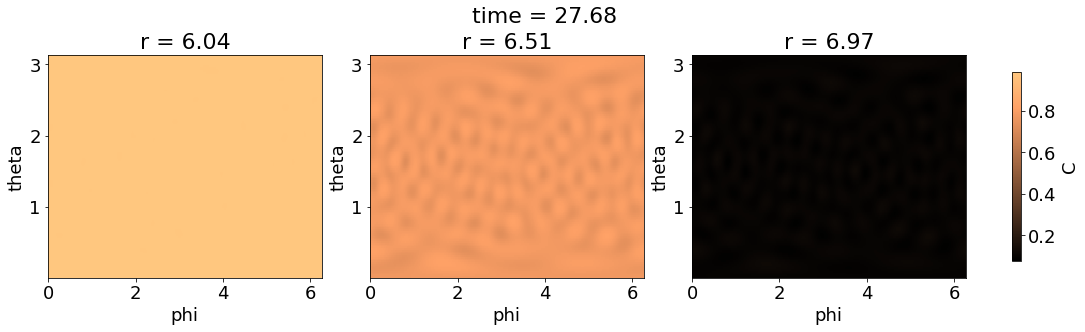

In [6]:
# ============================================================
# Example calls
# ============================================================

# Example 1: scalar temperature field
make_shell_rslices_animation(
    snapshot_dir="snapshots_md",
    file_prefix="snapshots_md_s",
    field_task="C",
    component_index=None,
    r_indices=(8, 32, -8),
    output_name="C_rslices_md.gif",
    fps=4,
    dpi=150,
    cmap="copper",
)

Found 23 files.
Scanning snapshots_md/snapshots_md_s1.h5
Scanning snapshots_md/snapshots_md_s2.h5
Scanning snapshots_md/snapshots_md_s3.h5
Scanning snapshots_md/snapshots_md_s4.h5
Scanning snapshots_md/snapshots_md_s5.h5
Scanning snapshots_md/snapshots_md_s6.h5
Scanning snapshots_md/snapshots_md_s7.h5
Scanning snapshots_md/snapshots_md_s8.h5
Scanning snapshots_md/snapshots_md_s9.h5
Scanning snapshots_md/snapshots_md_s10.h5
Scanning snapshots_md/snapshots_md_s11.h5
Scanning snapshots_md/snapshots_md_s12.h5
Scanning snapshots_md/snapshots_md_s13.h5
Scanning snapshots_md/snapshots_md_s14.h5
Scanning snapshots_md/snapshots_md_s15.h5
Scanning snapshots_md/snapshots_md_s16.h5
Scanning snapshots_md/snapshots_md_s17.h5
Scanning snapshots_md/snapshots_md_s18.h5
Scanning snapshots_md/snapshots_md_s19.h5
Scanning snapshots_md/snapshots_md_s20.h5
Scanning snapshots_md/snapshots_md_s21.h5
Scanning snapshots_md/snapshots_md_s22.h5
Scanning snapshots_md/snapshots_md_s23.h5
Total frames: 224
phi shape

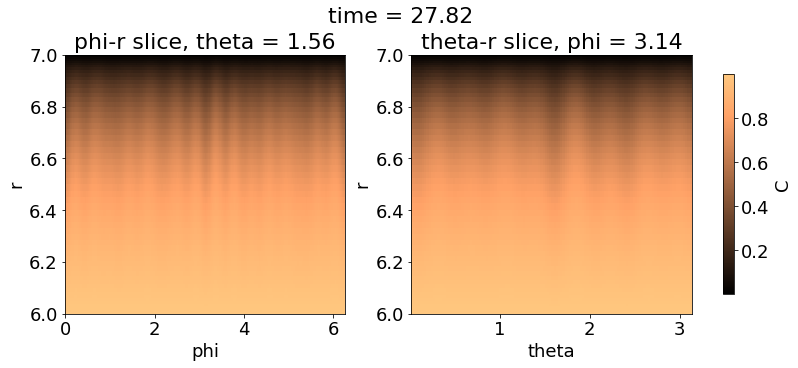

In [8]:
make_shell_vertical_slices_animation(
    snapshot_dir="snapshots_md",
    file_prefix="snapshots_md_s",
    field_task="C",
    component_index=None,
    theta_index=None,      # None means middle theta
    phi_index=None,        # None means middle phi
    output_name="C_vertslices_md.gif",
    fps=4,
    dpi=150,
    cmap="copper",
)

Found 3 files.
Scanning snapshots_ng/snapshots_s1.h5
Scanning snapshots_ng/snapshots_s2.h5
Scanning snapshots_ng/snapshots_s3.h5
Total frames: 24
phi shape: (256,) min/max: 0.0 6.258641614573416
theta shape: (128,) min/max: 0.01871454855517081 3.122878105034623
r shape: (64,) min/max: 6.000150590651898 6.999849409348102
r_index 8: r = 6.042895122148234
r_index 32: r = 6.512270614261456
r_index -8: r = 6.96649639941737
Scanning values for color limits...
vmin/vmax: -32.6157083601739 35.62350154428998
Frame 1/24: snapshots_ng/snapshots_s1.h5, index 0, time 0.00
Frame 1/24: snapshots_ng/snapshots_s1.h5, index 0, time 0.00
Frame 2/24: snapshots_ng/snapshots_s1.h5, index 1, time 0.09
Frame 3/24: snapshots_ng/snapshots_s1.h5, index 2, time 0.10
Frame 4/24: snapshots_ng/snapshots_s1.h5, index 3, time 0.10
Frame 5/24: snapshots_ng/snapshots_s1.h5, index 4, time 0.11
Frame 6/24: snapshots_ng/snapshots_s1.h5, index 5, time 0.12
Frame 7/24: snapshots_ng/snapshots_s1.h5, index 6, time 0.13
Frame 8

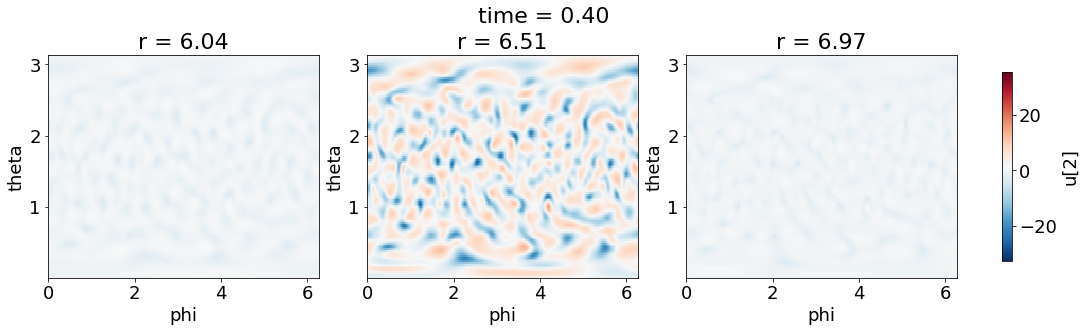

In [13]:
# ============================================================
# Example calls
# ============================================================

# Example 1: scalar temperature field
make_shell_rslices_animation(
    snapshot_dir="snapshots_ng",
    file_prefix="snapshots_s",
    field_task="u",
    component_index=2,
    r_indices=(8, 32, -8),
    output_name="w_rslices_ng.gif",
    fps=4,
    dpi=150,
    cmap="RdBu_r",
)

Found 9 snapshot files.
Scanning snapshots/snapshots_s1.h5
Scanning snapshots/snapshots_s2.h5
Scanning snapshots/snapshots_s3.h5
Scanning snapshots/snapshots_s4.h5
Scanning snapshots/snapshots_s5.h5
Scanning snapshots/snapshots_s6.h5
Scanning snapshots/snapshots_s7.h5
Scanning snapshots/snapshots_s8.h5
Scanning snapshots/snapshots_s9.h5
Total animation frames: 85
w color limits: -4.9256e+00, 4.9256e+00
x shape: (128,) x min/max: 0.0 3.96875
y shape: (128,) y min/max: 0.0 3.96875
z shape: (64,) z min/max: 0.00015059065189787502 0.9998494093481021
plotting z = 0.9878510650192642
Frame 1/85: snapshots/snapshots_s1.h5, index 0, time 0.00
Frame 1/85: snapshots/snapshots_s1.h5, index 0, time 0.00
Frame 2/85: snapshots/snapshots_s1.h5, index 1, time 0.10
Frame 3/85: snapshots/snapshots_s1.h5, index 2, time 0.10
Frame 4/85: snapshots/snapshots_s1.h5, index 3, time 0.10
Frame 5/85: snapshots/snapshots_s1.h5, index 4, time 0.10
Frame 6/85: snapshots/snapshots_s1.h5, index 5, time 0.10
Frame 7/85

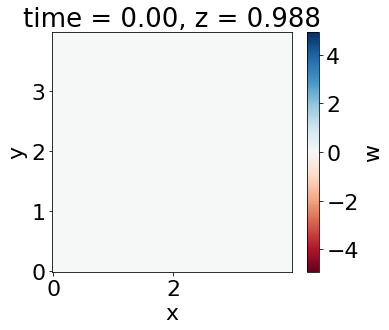

In [16]:
### MAKE ANIMATION OF LATERAL X-Y SLICE ###

# ----------------------------
# User settings
# ----------------------------
snapshot_dir = "snapshots"
file_prefix = "snapshots_s"
output_name = "mantle3D_xyperiodic_z-top_wC.gif"

z_index = -5          # fixed z-index for x-y slice
fps = 4
dpi = 150

C_levels = [0.25, 0.5, 0.75]  

# Brown -> olive -> green colormap
C_cmap = mcolors.LinearSegmentedColormap.from_list(
    "brown_to_green",
    ["saddlebrown", "olive", "forestgreen"]
)

C_colors = [C_cmap(i) for i in np.linspace(0, 1, len(C_levels))]

# Optional: set color limits manually, or leave as None
w_vmin = None
w_vmax = None

# ----------------------------
# Helper: get coordinate arrays from Dedalus HDF5 output
# ----------------------------
def get_coord(dset, dim_index):
    """
    Get coordinate scale from an HDF5 dataset dimension.
    For data shaped (t, nx, ny, nz):
        dim 0 = time
        dim 1 = x
        dim 2 = y
        dim 3 = z
    """
    keys = list(dset.dims[dim_index].keys())

    if len(keys) == 0:
        raise ValueError(f"No coordinate scale found for dimension {dim_index}")

    # Usually Dedalus stores the coordinate as the first/only scale.
    return np.asarray(dset.dims[dim_index][keys[0]])

# ----------------------------
# Find files in order
# ----------------------------
files = []
i = 1
while True:
    fname = os.path.join(snapshot_dir, f"{file_prefix}{i}.h5")
    if os.path.exists(fname):
        files.append(fname)
        i += 1
    else:
        break

if len(files) == 0:
    raise FileNotFoundError(f"No files found like {snapshot_dir}/{file_prefix}X.h5")

print(f"Found {len(files)} snapshot files.")

# ----------------------------
# First pass: collect frame metadata and global w limits
# ----------------------------
frames = []

if w_vmin is None or w_vmax is None:
    global_min = np.inf
    global_max = -np.inf

for fname in files:
    print(f"Scanning {fname}")
    with h5py.File(fname, mode="r") as file:
        w_dset = file["tasks"]["w"]
        T_dset = file["tasks"]["T"]
        t = np.asarray(T_dset.dims[0]["sim_time"])

        nt = w_dset.shape[0]

        for it in range(nt):
            frames.append((fname, it, t[it]))

        if w_vmin is None or w_vmax is None:
            w_slice_all = np.asarray(w_dset[int(nt/2):, :, :, z_index])

            w_rms = np.sqrt(np.nanmean(w_slice_all**2))
            w_lim = 1.5 * w_rms

            global_min = min(global_min, -w_lim)
            global_max = max(global_max,  w_lim)

if w_vmin is None:
    w_vmin = global_min
if w_vmax is None:
    w_vmax = global_max

# Symmetric color scale about zero
w_abs = max(abs(w_vmin), abs(w_vmax))
w_vmin = -w_abs
w_vmax = w_abs

print(f"Total animation frames: {len(frames)}")
print(f"w color limits: {w_vmin:.4e}, {w_vmax:.4e}")

# ----------------------------
# Load first frame and actual coordinate arrays
# ----------------------------
first_fname, first_it, first_time = frames[0]

with h5py.File(first_fname, mode="r") as file:
    w_dset = file["tasks"]["w"]

    w0 = np.asarray(file["tasks"]["w"][first_it, :, :, z_index])
    C0 = np.asarray(file["tasks"]["C"][first_it, :, :, z_index])

    x = get_coord(w_dset, 1)
    y = get_coord(w_dset, 2)
    z = get_coord(w_dset, 3)

print("x shape:", x.shape, "x min/max:", x.min(), x.max())
print("y shape:", y.shape, "y min/max:", y.min(), y.max())
print("z shape:", z.shape, "z min/max:", z.min(), z.max())
print("plotting z =", z[z_index])

nx, ny = w0.shape

if len(x) != nx:
    raise ValueError(f"x coordinate length {len(x)} does not match nx {nx}")
if len(y) != ny:
    raise ValueError(f"y coordinate length {len(y)} does not match ny {ny}")

X, Y = np.meshgrid(x, y, indexing="ij")

# ----------------------------
# Figure setup
# ----------------------------
fig, ax = plt.subplots(figsize=(6, 5))

pcm = ax.pcolormesh(
    X, Y, w0,
    shading="auto",
    vmin=w_vmin,
    vmax=w_vmax,
    cmap="RdBu"
)

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label("w")

contours = ax.contour(
    X, Y, C0,          
    levels=C_levels,
    colors=C_colors,
    linewidths=1.0,
)

ax.clabel(contours, inline=True, fontsize=8)

title = ax.set_title(f"time = {first_time:.2f}, z = {z[z_index]:.3g}")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")

plt.tight_layout()

# ----------------------------
# Animation update function
# ----------------------------
def update(frame_number):
    global contours

    fname, it, sim_time = frames[frame_number]

    with h5py.File(fname, mode="r") as file:
        w_slice = np.asarray(file["tasks"]["w"][it, :, :, z_index])
        C_slice = np.asarray(file["tasks"]["C"][it, :, :, z_index])

    pcm.set_array(w_slice.ravel())

    # Remove old contours
    for coll in contours.collections:
        coll.remove()

    # Draw new contours
    contours = ax.contour(
        X, Y, C_slice,      
        levels=C_levels,
        colors=C_colors,
        linewidths=1.0,
    )

    title.set_text(f"time = {sim_time:.2f}, z = {z[z_index]:.3g}")

    print(
        f"Frame {frame_number + 1}/{len(frames)}: "
        f"{fname}, index {it}, time {sim_time:.2f}"
    )

    return [pcm, title] + contours.collections

# ----------------------------
# Save animation
# ----------------------------
ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=1000 / fps,
    blit=False,
)

ani.save(output_name, writer="pillow", fps=fps, dpi=dpi)

print(f"Saved animation to {output_name}")

Found 9 snapshot files.
Scanning snapshots/snapshots_s1.h5
Scanning snapshots/snapshots_s2.h5
Scanning snapshots/snapshots_s3.h5
Scanning snapshots/snapshots_s4.h5
Scanning snapshots/snapshots_s5.h5
Scanning snapshots/snapshots_s6.h5
Scanning snapshots/snapshots_s7.h5
Scanning snapshots/snapshots_s8.h5
Scanning snapshots/snapshots_s9.h5
Total animation frames: 85
w color limits: -6.5675e+00, 6.5675e+00
x shape: (128,) x min/max: 0.0 3.96875
y shape: (128,) y min/max: 0.0 3.96875
z shape: (64,) z min/max: 0.00015059065189787502 0.9998494093481021
plotting y = 2.0
Frame 1/85: snapshots/snapshots_s1.h5, index 0, time 0.00
Frame 1/85: snapshots/snapshots_s1.h5, index 0, time 0.00
Frame 2/85: snapshots/snapshots_s1.h5, index 1, time 0.10
Frame 3/85: snapshots/snapshots_s1.h5, index 2, time 0.10
Frame 4/85: snapshots/snapshots_s1.h5, index 3, time 0.10
Frame 5/85: snapshots/snapshots_s1.h5, index 4, time 0.10
Frame 6/85: snapshots/snapshots_s1.h5, index 5, time 0.10
Frame 7/85: snapshots/sna

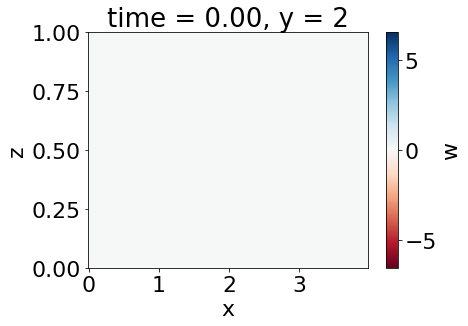

In [17]:
### MAKE ANIMATION OF VERTICAL X-Z SLICE ###

# ----------------------------
# User settings
# ----------------------------
snapshot_dir = "snapshots"
file_prefix = "snapshots_s"
output_name = "mantle3D_xyperiodic_y-64_wC.gif"

y_index = 64          # fixed y-index for x-z slice
fps = 4
dpi = 150

C_levels = [0.1, 0.3, 0.5, 0.7]  

# Brown -> olive -> green colormap
C_cmap = mcolors.LinearSegmentedColormap.from_list(
    "brown_to_green",
    ["saddlebrown", "olive", "forestgreen"]
)

C_colors = [C_cmap(i) for i in np.linspace(0, 1, len(C_levels))]

# Optional: set color limits manually, or leave as None
w_vmin = None
w_vmax = None

# ----------------------------
# Helper: get coordinate arrays from Dedalus HDF5 output
# ----------------------------
def get_coord(dset, dim_index):
    """
    Get coordinate scale from an HDF5 dataset dimension.
    For data shaped (t, nx, ny, nz):
        dim 0 = time
        dim 1 = x
        dim 2 = y
        dim 3 = z
    """
    keys = list(dset.dims[dim_index].keys())

    if len(keys) == 0:
        raise ValueError(f"No coordinate scale found for dimension {dim_index}")

    return np.asarray(dset.dims[dim_index][keys[0]])

# ----------------------------
# Find files in order
# ----------------------------
files = []
i = 1
while True:
    fname = os.path.join(snapshot_dir, f"{file_prefix}{i}.h5")
    if os.path.exists(fname):
        files.append(fname)
        i += 1
    else:
        break

if len(files) == 0:
    raise FileNotFoundError(f"No files found like {snapshot_dir}/{file_prefix}X.h5")

print(f"Found {len(files)} snapshot files.")

# ----------------------------
# First pass: collect frame metadata and global w limits
# ----------------------------
frames = []

if w_vmin is None or w_vmax is None:
    global_min = np.inf
    global_max = -np.inf

for fname in files:
    print(f"Scanning {fname}")
    with h5py.File(fname, mode="r") as file:
        w_dset = file["tasks"]["w"]
        T_dset = file["tasks"]["T"]
        t = np.asarray(T_dset.dims[0]["sim_time"])

        nt = w_dset.shape[0]

        for it in range(nt):
            frames.append((fname, it, t[it]))

        if w_vmin is None or w_vmax is None:
            w_slice_all = np.asarray(w_dset[int(nt/2):, :, :, z_index])

            w_rms = np.sqrt(np.nanmean(w_slice_all**2))
            w_lim = 2.0 * w_rms

            global_min = min(global_min, -w_lim)
            global_max = max(global_max,  w_lim)

if w_vmin is None:
    w_vmin = global_min
if w_vmax is None:
    w_vmax = global_max

# Symmetric color scale about zero
w_abs = max(abs(w_vmin), abs(w_vmax))
w_vmin = -w_abs
w_vmax = w_abs

print(f"Total animation frames: {len(frames)}")
print(f"w color limits: {w_vmin:.4e}, {w_vmax:.4e}")

# ----------------------------
# Load first frame and actual coordinate arrays
# ----------------------------
first_fname, first_it, first_time = frames[0]

with h5py.File(first_fname, mode="r") as file:
    w_dset = file["tasks"]["w"]

    w0 = np.asarray(file["tasks"]["w"][first_it, :, y_index, :])
    C0 = np.asarray(file["tasks"]["C"][first_it, :, y_index, :])

    x = get_coord(w_dset, 1)
    y = get_coord(w_dset, 2)
    z = get_coord(w_dset, 3)

print("x shape:", x.shape, "x min/max:", x.min(), x.max())
print("y shape:", y.shape, "y min/max:", y.min(), y.max())
print("z shape:", z.shape, "z min/max:", z.min(), z.max())
print("plotting y =", y[y_index])

nx, nz = w0.shape

if len(x) != nx:
    raise ValueError(f"x coordinate length {len(x)} does not match nx {nx}")
if len(z) != nz:
    raise ValueError(f"z coordinate length {len(z)} does not match nz {nz}")

X, Z = np.meshgrid(x, z, indexing="ij")

# ----------------------------
# Figure setup
# ----------------------------
fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    X, Z, w0,
    shading="auto",
    vmin=w_vmin,
    vmax=w_vmax,
    cmap="RdBu"
)

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label("w")

contours = ax.contour(
    X, Z, C0,
    levels=C_levels,
    colors=C_colors,
    linewidths=0.8,
)

ax.clabel(contours, inline=True, fontsize=8)

title = ax.set_title(f"time = {first_time:.2f}, y = {y[y_index]:.3g}")
ax.set_xlabel("x")
ax.set_ylabel("z")

# If z=0 is bottom, leave this commented.
# If your plots look upside down, uncomment it.
# ax.invert_yaxis()

plt.tight_layout()

# ----------------------------
# Animation update function
# ----------------------------
def update(frame_number):
    global contours

    fname, it, sim_time = frames[frame_number]

    with h5py.File(fname, mode="r") as file:
        w_slice = np.asarray(file["tasks"]["w"][it, :, y_index, :])
        C_slice = np.asarray(file["tasks"]["C"][it, :, y_index, :])

    pcm.set_array(w_slice.ravel())

    # Remove old contours
    for coll in contours.collections:
        coll.remove()

    # Draw new contours
    contours = ax.contour(
        X, Z, C_slice,
        levels=C_levels,
        colors=C_colors,
        linewidths=0.8,
    )

    title.set_text(f"time = {sim_time:.2f}, y = {y[y_index]:.3g}")

    print(
        f"Frame {frame_number + 1}/{len(frames)}: "
        f"{fname}, index {it}, time {sim_time:.2f}"
    )

    return [pcm, title] + contours.collections

# ----------------------------
# Save animation
# ----------------------------
ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=1000 / fps,
    blit=False,
)

ani.save(output_name, writer="pillow", fps=fps, dpi=dpi)

print(f"Saved animation to {output_name}")

Found 9 snapshot files.
Scanning snapshots/snapshots_s1.h5
Scanning snapshots/snapshots_s2.h5
Scanning snapshots/snapshots_s3.h5
Scanning snapshots/snapshots_s4.h5
Scanning snapshots/snapshots_s5.h5
Scanning snapshots/snapshots_s6.h5
Scanning snapshots/snapshots_s7.h5
Scanning snapshots/snapshots_s8.h5
Scanning snapshots/snapshots_s9.h5


<ipython-input-32-5bb9101c5baf>:81: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  contour_cmap = cm.get_cmap("RdBu")


Total animation frames: 89
x shape: (128,) x min/max: 0.0 3.96875
y shape: (128,) y min/max: 0.0 3.96875
z shape: (64,) z min/max: 0.00015059065189787502 0.9998494093481021
plotting y = 2.0
Frame 1/89: snapshots/snapshots_s1.h5, index 0, time 0.00
Frame 1/89: snapshots/snapshots_s1.h5, index 0, time 0.00
Frame 2/89: snapshots/snapshots_s1.h5, index 1, time 0.10
Frame 3/89: snapshots/snapshots_s1.h5, index 2, time 0.10
Frame 4/89: snapshots/snapshots_s1.h5, index 3, time 0.10
Frame 5/89: snapshots/snapshots_s1.h5, index 4, time 0.10
Frame 6/89: snapshots/snapshots_s1.h5, index 5, time 0.10
Frame 7/89: snapshots/snapshots_s1.h5, index 6, time 0.10
Frame 8/89: snapshots/snapshots_s1.h5, index 7, time 0.10
Frame 9/89: snapshots/snapshots_s1.h5, index 8, time 0.11
Frame 10/89: snapshots/snapshots_s1.h5, index 9, time 0.11
Frame 11/89: snapshots/snapshots_s2.h5, index 0, time 0.11
Frame 12/89: snapshots/snapshots_s2.h5, index 1, time 0.11
Frame 13/89: snapshots/snapshots_s2.h5, index 2, time

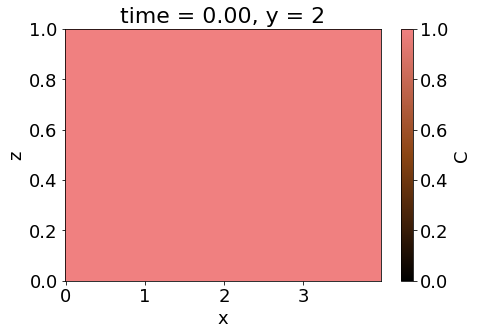

In [32]:
### MAKE ANIMATION OF VERTICAL X-Z SLICE ###

# ----------------------------
# User settings
# ----------------------------
snapshot_dir = "snapshots"
file_prefix = "snapshots_s"
output_name = "mantle3D_xyperiodic_y-64_Cvort.gif"

y_index = 64          # fixed y-index for x-z slice
fps = 4
dpi = 150

V_levels = np.asarray([-0.25,-0.2,-0.15,-0.1,-0.05,0.05,0.1,0.15,0.2,0.25])

C_cmap = mcolors.LinearSegmentedColormap.from_list(
    "brown_to_red",
    ["black", "saddlebrown", "lightcoral"]
)

C_vmin = 0
C_vmax = 1

# ----------------------------
# Helper: get coordinate arrays from Dedalus HDF5 output
# ----------------------------
def get_coord(dset, dim_index):
    """
    Get coordinate scale from an HDF5 dataset dimension.
    For data shaped (t, nx, ny, nz):
        dim 0 = time
        dim 1 = x
        dim 2 = y
        dim 3 = z
    """
    keys = list(dset.dims[dim_index].keys())

    if len(keys) == 0:
        raise ValueError(f"No coordinate scale found for dimension {dim_index}")

    return np.asarray(dset.dims[dim_index][keys[0]])

# ----------------------------
# Find files in order
# ----------------------------
files = []
i = 1
while True:
    fname = os.path.join(snapshot_dir, f"{file_prefix}{i}.h5")
    if os.path.exists(fname):
        files.append(fname)
        i += 1
    else:
        break

if len(files) == 0:
    raise FileNotFoundError(f"No files found like {snapshot_dir}/{file_prefix}X.h5")

print(f"Found {len(files)} snapshot files.")

# ----------------------------
# First pass: collect frame metadata and global V limits
# ----------------------------
frames = []
Vmax_frames = []

for fname in files:
    print(f"Scanning {fname}")
    with h5py.File(fname, mode="r") as file:
        V_dset = file["tasks"]["vorticity_y"]
        t = np.asarray(V_dset.dims[0]["sim_time"])
        nt = V_dset.shape[0]

        for it in range(nt):
            frames.append((fname, it, t[it]))
            Vmax_frames.append(np.nanmax(np.abs(V_dset[it, ...])))

Vscale = np.nanmax(Vmax_frames[len(Vmax_frames)//2:])
V_levels *= 0.8*Vscale

contour_cmap = cm.get_cmap("RdBu")
contour_norm = mcolors.Normalize(vmin=-Vscale/10, vmax=Vscale/10, clip=True)

V_colors = [contour_cmap(contour_norm(level)) for level in V_levels]

print(f"Total animation frames: {len(frames)}")

# ----------------------------
# Load first frame and actual coordinate arrays
# ----------------------------
first_fname, first_it, first_time = frames[0]

with h5py.File(first_fname, mode="r") as file:
    C_dset = file["tasks"]["C"]

    C0 = np.asarray(file["tasks"]["C"][first_it, :, y_index, :])
    V0 = np.asarray(file["tasks"]["vorticity_y"][first_it, :, y_index, :])

    x = get_coord(C_dset, 1)
    y = get_coord(C_dset, 2)
    z = get_coord(C_dset, 3)

print("x shape:", x.shape, "x min/max:", x.min(), x.max())
print("y shape:", y.shape, "y min/max:", y.min(), y.max())
print("z shape:", z.shape, "z min/max:", z.min(), z.max())
print("plotting y =", y[y_index])

nx, nz = w0.shape

if len(x) != nx:
    raise ValueError(f"x coordinate length {len(x)} does not match nx {nx}")
if len(z) != nz:
    raise ValueError(f"z coordinate length {len(z)} does not match nz {nz}")

X, Z = np.meshgrid(x, z, indexing="ij")

# ----------------------------
# Figure setup
# ----------------------------
fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    X, Z, C0,
    shading="auto",
    vmin=C_vmin,
    vmax=C_vmax,
    cmap=C_cmap
)

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label("C")

contours = ax.contour(
    X, Z, V0,
    levels=V_levels,
    colors=V_colors,
    linewidths=0.8,
)

ax.clabel(contours, inline=True, fontsize=8)

title = ax.set_title(f"time = {first_time:.2f}, y = {y[y_index]:.3g}")
ax.set_xlabel("x")
ax.set_ylabel("z")

# If z=0 is bottom, leave this commented.
# If your plots look upside down, uncomment it.
# ax.invert_yaxis()

plt.tight_layout()

# ----------------------------
# Animation update function
# ----------------------------
def update(frame_number):
    global contours

    fname, it, sim_time = frames[frame_number]

    with h5py.File(fname, mode="r") as file:
        C_slice = np.asarray(file["tasks"]["C"][it, :, y_index, :])
        V_slice = np.asarray(file["tasks"]["vorticity_y"][it, :, y_index, :])

    pcm.set_array(C_slice.ravel())

    # Remove old contours
    for coll in contours.collections:
        coll.remove()

    # Draw new contours
    contours = ax.contour(
        X, Z, V_slice,
        levels=V_levels,
        colors=V_colors,
        linewidths=0.8,
    )

    title.set_text(f"time = {sim_time:.2f}, y = {y[y_index]:.3g}")

    print(
        f"Frame {frame_number + 1}/{len(frames)}: "
        f"{fname}, index {it}, time {sim_time:.2f}"
    )

    return [pcm, title] + contours.collections

# ----------------------------
# Save animation
# ----------------------------
ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=1000 / fps,
    blit=False,
)

ani.save(output_name, writer="pillow", fps=fps, dpi=dpi)

print(f"Saved animation to {output_name}")

Loaded KE from stdout:
KE_times shape: (843,)
KE shape: (843,)
KE time range: 0.02 1.546066
Loading T snapshots...
snapshots/snapshots_s1.h5
snapshots/snapshots_s2.h5
snapshots/snapshots_s3.h5
snapshots/snapshots_s4.h5
snapshots/snapshots_s5.h5
snapshots/snapshots_s6.h5
snapshots/snapshots_s7.h5
snapshots/snapshots_s8.h5
snapshots/snapshots_s9.h5
T_times shape: (85,)
Tbar_profiles shape: (85, 64)
z_T shape: (64,)
Loading nonlinear diagnostics...
snapshots_nonlinear/snapshots_nonlinear_s1.h5
snapshots_nonlinear/snapshots_nonlinear_s2.h5
snapshots_nonlinear/snapshots_nonlinear_s3.h5
snapshots_nonlinear/snapshots_nonlinear_s4.h5
snapshots_nonlinear/snapshots_nonlinear_s5.h5
chf_times shape: (844,)
chf_profiles shape: (844, 64)
z_chf shape: (1,)
Nu_times shape: (85,)
Nu_profiles shape: (85, 64)
Nu_global shape: (85,)
         np.interp used endpoint KE values outside available KE range.
Using samples 42 through 84 for axis limits.
Saved KE_Nu_base.png
GIF frame 1/85: time = 0.00
GIF frame 

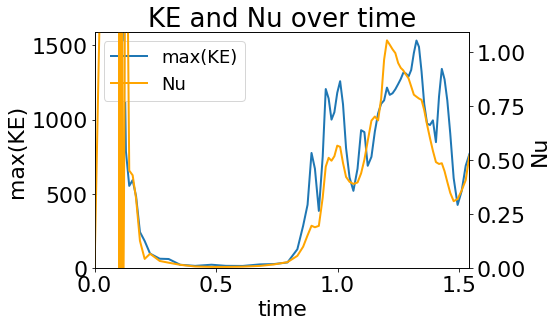

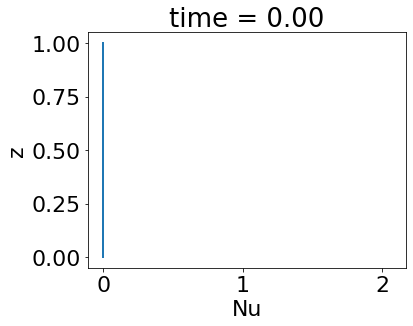

In [15]:
### Nu and KE ANALYSIS ###

# ============================================================
# User settings
# ============================================================
snap_dir = "snapshots"
nonlinear_dir = "snapshots_nonlinear"

# stdout / log file containing lines with max(KE)=...
stdout_file = "stdout.531863"

output_timeseries = "KE_Nu_base.png"
output_gif = "Nu_zprof_base.gif"

fps = 6
dpi = 150

# ============================================================
# Helpers
# ============================================================
def natural_sort_key(path):
    return [int(s) if s.isdigit() else s for s in re.split(r"(\d+)", path)]

def get_h5_files(folder):
    files = sorted(glob.glob(os.path.join(folder, "*.h5")), key=natural_sort_key)
    if len(files) == 0:
        raise FileNotFoundError(f"No .h5 files found in {folder}")
    return files

def get_time_from_task(dset):
    return np.asarray(dset.dims[0]["sim_time"])

def get_coord(dset, dim_index):
    keys = list(dset.dims[dim_index].keys())
    if len(keys) == 0:
        raise ValueError(f"No coordinate scale found for dimension {dim_index}")
    return np.asarray(dset.dims[dim_index][keys[0]])

def squeeze_task(arr):
    return np.squeeze(np.asarray(arr))

def load_ke_from_stdout(stdout_file):
    """
    Extract Time and max(KE) from lines like:

    Iteration=621, Time=1.035369e-01, dt=9.722929e-06, max(KE)=114422.473896
    """
    times = []
    kes = []

    pattern = re.compile(
        r"Time=([+-]?\d+(?:\.\d*)?(?:[eE][+-]?\d+)?).*?"
        r"max\(KE\)=([+-]?\d+(?:\.\d*)?(?:[eE][+-]?\d+)?)"
    )

    with open(stdout_file, "r") as f:
        for line in f:
            match = pattern.search(line)
            if match is not None:
                times.append(float(match.group(1)))
                kes.append(float(match.group(2)))

    if len(times) == 0:
        raise ValueError(f"No KE lines found in {stdout_file}")

    times = np.asarray(times)
    kes = np.asarray(kes)

    order = np.argsort(times)
    return times[order], kes[order]

def pad_limits(vmin, vmax, frac=0.05):
    pad = frac * (vmax - vmin)
    if pad == 0 or not np.isfinite(pad):
        center = 0.5 * (vmin + vmax)
        pad = frac * abs(center)
        if pad == 0 or not np.isfinite(pad):
            pad = frac
    return vmin - pad, vmax + pad

# ============================================================
# Load KE from stdout
# ============================================================
KE_times_raw, KE_raw = load_ke_from_stdout(stdout_file)

print("Loaded KE from stdout:")
print("KE_times shape:", KE_times_raw.shape)
print("KE shape:", KE_raw.shape)
print("KE time range:", KE_times_raw.min(), KE_times_raw.max())

# ============================================================
# Load T snapshots and compute horizontally averaged T(z,t)
# ============================================================
snap_files = get_h5_files(snap_dir)

T_times = []
Tbar_profiles = []

z_T = None

print("Loading T snapshots...")

for fname in snap_files:
    print(fname)
    with h5py.File(fname, "r") as f:
        T_dset = f["tasks"]["T"]
        t = get_time_from_task(T_dset)
        T = np.asarray(T_dset)  # expected shape: (t, nx, ny, nz)

        if z_T is None:
            z_T = get_coord(T_dset, 3)

        # horizontally averaged T(z)
        Tbar = np.nanmean(T, axis=(1, 2))  # shape: (nt, nz)

        T_times.append(t)
        Tbar_profiles.append(Tbar)

T_times = np.concatenate(T_times)
Tbar_profiles = np.concatenate(Tbar_profiles, axis=0)

order = np.argsort(T_times)
T_times = T_times[order]
Tbar_profiles = Tbar_profiles[order, :]

print("T_times shape:", T_times.shape)
print("Tbar_profiles shape:", Tbar_profiles.shape)
print("z_T shape:", z_T.shape)

# ============================================================
# Load nonlinear diagnostics: convective_heat_flux_z
# ============================================================
nonlinear_files = get_h5_files(nonlinear_dir)

chf_times = []
chf_profiles = []

z_chf = None

print("Loading nonlinear diagnostics...")

for fname in nonlinear_files:
    print(fname)
    with h5py.File(fname, "r") as f:
        chf_dset = f["tasks"]["convective_heat_flux_z"]
        t_chf = get_time_from_task(chf_dset)
        chf = squeeze_task(chf_dset)

        if z_chf is None:
            z_chf = get_coord(chf_dset, 1)

        chf_times.append(t_chf)
        chf_profiles.append(chf)

chf_times = np.concatenate(chf_times)
chf_profiles = np.concatenate(chf_profiles, axis=0)

order = np.argsort(chf_times)
chf_times = chf_times[order]
chf_profiles = chf_profiles[order, :]

print("chf_times shape:", chf_times.shape)
print("chf_profiles shape:", chf_profiles.shape)
print("z_chf shape:", z_chf.shape)

# ============================================================
# Compute Nu at each T snapshot time
# ============================================================
Nu_times = []
Nu_profiles = []
Nu_global = []

for i, t0 in enumerate(T_times):
    # interval around this T sample
    if i == 0:
        t_left = -np.inf
    else:
        t_left = 0.5 * (T_times[i - 1] + T_times[i])

    if i == len(T_times) - 1:
        t_right = np.inf
    else:
        t_right = 0.5 * (T_times[i] + T_times[i + 1])

    mask = (chf_times >= t_left) & (chf_times < t_right)

    if not np.any(mask):
        # fallback: nearest convective heat flux sample
        j = np.argmin(np.abs(chf_times - t0))
        chf_mean_z = chf_profiles[j, :]
    else:
        chf_mean_z = np.nanmean(chf_profiles[mask, :], axis=0)

    Tbar_z = Tbar_profiles[i, :]

    dTdz = np.gradient(Tbar_z, z_T, edge_order=2)

    # Requested definition:
    # Nu(z) = <wT>_xy / (-d<T>_xy/dz)
    Nu_z = chf_mean_z / (-dTdz)

    Nu_times.append(t0)
    Nu_profiles.append(Nu_z)

    Nu_mean = np.trapz(Nu_z, z_T) / (z_T[-1] - z_T[0])
    Nu_global.append(Nu_mean)

Nu_times = np.asarray(Nu_times)
Nu_profiles = np.asarray(Nu_profiles)
Nu_global = np.asarray(Nu_global)

print("Nu_times shape:", Nu_times.shape)
print("Nu_profiles shape:", Nu_profiles.shape)
print("Nu_global shape:", Nu_global.shape)

# ============================================================
# Sample/interpolate KE onto Nu times
# ============================================================
# This gives KE with exactly as many points as Nu.
KE_at_Nu_times = np.interp(Nu_times, KE_times_raw, KE_raw)

if Nu_times.min() < KE_times_raw.min() or Nu_times.max() > KE_times_raw.max():
    print("WARNING: Nu time range extends outside KE stdout time range.")
    print("         np.interp used endpoint KE values outside available KE range.")

# ============================================================
# Last quarter samples for axis limits
# ============================================================
n_samples = len(Nu_times)
iq0 = int(0.5 * n_samples)

Nu_times_lq = Nu_times[iq0:]
Nu_profiles_lq = Nu_profiles[iq0:, :]
Nu_global_lq = Nu_global[iq0:]
KE_lq = KE_at_Nu_times[iq0:]

print(f"Using samples {iq0} through {n_samples - 1} for axis limits.")

# ============================================================
# Plot KE and Nu time series with two y axes
# Axis limits based only on last quarter of samples
# ============================================================
fig, ax1 = plt.subplots(figsize=(8, 5))

line1, = ax1.plot(Nu_times, KE_at_Nu_times, linewidth=2, label="max(KE)")
ax1.set_xlabel("time")
ax1.set_ylabel("max(KE)")

ax2 = ax1.twinx()
line2, = ax2.plot(Nu_times, Nu_global, linewidth=2, color='orange', label="Nu")
ax2.set_ylabel("Nu")

# Show full time range, but scale y-limits from last quarter only.
ax1.set_xlim(Nu_times.min(), Nu_times.max())

KE_ymin, KE_ymax = pad_limits(np.nanmin(KE_lq), np.nanmax(KE_lq))
Nu_ymin, Nu_ymax = pad_limits(np.nanmin(Nu_global_lq), np.nanmax(Nu_global_lq))

ax1.set_ylim(0, KE_ymax)
ax2.set_ylim(0, Nu_ymax)

ax1.set_title("KE and Nu over time")

lines = [line1, line2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="best")

fig.tight_layout()
fig.savefig(output_timeseries, dpi=dpi)
print(f"Saved {output_timeseries}")

# ============================================================
# GIF: Nu(z) only
# Axis limits based only on last quarter of profiles
# ============================================================
Nu_vmin = np.nanpercentile(Nu_profiles_lq, 1)
Nu_vmax = np.nanpercentile(Nu_profiles_lq, 99)
Nu_vmin, Nu_vmax = pad_limits(Nu_vmin, Nu_vmax)

fig, ax = plt.subplots(figsize=(6, 5))

line_Nu, = ax.plot(Nu_profiles[0, :], z_T, linewidth=2)

ax.set_xlabel("Nu")
ax.set_ylabel("z")
ax.set_xlim(Nu_vmin, Nu_vmax)
ax.set_title(f"time = {Nu_times[0]:.2f}")

# For usual Dedalus z=0 bottom, Lz top, leave this commented.
# ax.invert_yaxis()

fig.tight_layout()

def update(frame):
    line_Nu.set_xdata(Nu_profiles[frame, :])
    ax.set_title(f"time = {Nu_times[frame]:.2f}")

    print(f"GIF frame {frame + 1}/{len(Nu_times)}: time = {Nu_times[frame]:.2f}")

    return [line_Nu]

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(Nu_times),
    interval=1000 / fps,
    blit=False,
)

ani.save(output_gif, writer="pillow", fps=fps, dpi=dpi)
print(f"Saved {output_gif}")